# 🏗️ Notebook 02 — Baseline: Transfer Learning (Head Only)

**Objetivo:** Establecer el punto de partida del modelo.

**Estrategia:** Cargar EfficientNet-B0 preentrenado en ImageNet, congelar el backbone completo,
y entrenar únicamente la cabeza de clasificación (101 neuronas) por ~5 épocas.

**Por qué este enfoque como baseline:**
- Rápido de entrenar (solo ~300K parámetros libres)
- Establece el piso antes del fine-tuning
- Esperado: ~60-70% Top-1 accuracy


In [1]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
from torchvision import datasets
from torch.utils.data import DataLoader

from src.config import (
    DATA_DIR, WEIGHTS_DIR, DEVICE, SEED, BATCH_SIZE,
    FOOD101_CLASSES, BASELINE_LR, BASELINE_EPOCHS
)
from src.model import build_model, freeze_backbone
from src.trainer import train_model, evaluate
from src.transforms import get_train_transform, get_val_transform
from src.utils import show_batch, plot_training_curves

# Reproducibilidad
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print(f'Device: {DEVICE}')
print(f'Batch size: {BATCH_SIZE}')

Device: mps
Batch size: 64


## 📁 Parte 1 — Carga del Dataset


Train: 75,750 imágenes (1184 batches)
Val:   25,250 imágenes (395 batches)


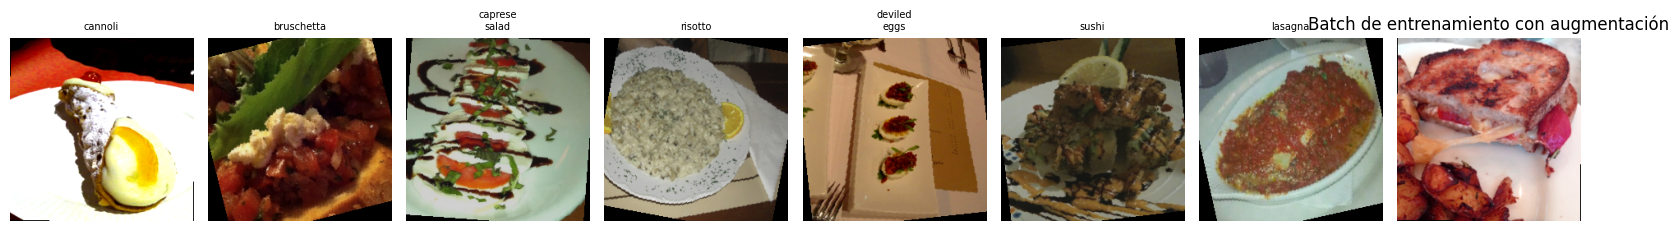

In [3]:
import matplotlib.pyplot as plt
train_dataset = datasets.Food101(
    root=str(DATA_DIR), split='train',
    transform=get_train_transform(), download=False
)
val_dataset = datasets.Food101(
    root=str(DATA_DIR), split='test',
    transform=get_val_transform(), download=False
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=4, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=4, pin_memory=True
)

print(f'Train: {len(train_dataset):,} imágenes ({len(train_loader)} batches)')
print(f'Val:   {len(val_dataset):,} imágenes ({len(val_loader)} batches)')

# Visualizar un batch de entrenamiento
images, labels = next(iter(train_loader))
label_names = [FOOD101_CLASSES[l] for l in labels[:8]]
show_batch(images, label_names)
plt.title('Batch de entrenamiento con augmentación')
plt.show()

## 🧠 Parte 2 — Construcción del Modelo


In [4]:
model = build_model(backbone='efficientnet_b0', num_classes=101, pretrained=True)
freeze_backbone(model, backbone='efficientnet_b0')
model = model.to(DEVICE)

# Verificar qué parámetros están activos
total_params   = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Parámetros totales:     {total_params:,}')
print(f'Parámetros entrenables: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)')
print(f'Parámetros congelados:  {total_params - trainable_params:,}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/nicok/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 34.3MB/s]


Parámetros totales:     4,136,929
Parámetros entrenables: 129,381 (3.1%)
Parámetros congelados:  4,007,548


## 🏋️ Parte 3 — Entrenamiento


In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=BASELINE_LR)

# Label smoothing reduce overfitting y mejora calibración de probabilidades
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print(f'Optimizer: Adam  lr={BASELINE_LR}')
print(f'Loss: CrossEntropyLoss con label_smoothing=0.1')
print(f'Épocas: {BASELINE_EPOCHS}')

WEIGHTS_DIR.mkdir(exist_ok=True)
save_path = WEIGHTS_DIR / 'baseline.pt'

history = train_model(
    model, train_loader, val_loader,
    epochs=BASELINE_EPOCHS,
    optimizer=optimizer,
    criterion=criterion,
    device=DEVICE,
    save_path=save_path,
    patience=10,  # sin early stopping en el baseline
)

Optimizer: Adam  lr=0.001
Loss: CrossEntropyLoss con label_smoothing=0.1
Épocas: 5

Época 1/5


  train loss=3.3430  acc=0.311  |  val loss=2.5223  top1=0.522  top5=0.774
  ✓ Guardado en /Users/nicok/Documents/MIA/Vision por computadora/TP Final/notebooks/../weights/baseline.pt  (top1=0.522)

Época 2/5


  train loss=2.9822  acc=0.388  |  val loss=2.4091  top1=0.546  top5=0.794
  ✓ Guardado en /Users/nicok/Documents/MIA/Vision por computadora/TP Final/notebooks/../weights/baseline.pt  (top1=0.546)

Época 3/5


  train loss=2.9339  acc=0.400  |  val loss=2.3663  top1=0.557  top5=0.803
  ✓ Guardado en /Users/nicok/Documents/MIA/Vision por computadora/TP Final/notebooks/../weights/baseline.pt  (top1=0.557)

Época 4/5


  train loss=2.9142  acc=0.404  |  val loss=2.3402  top1=0.563  top5=0.808
  ✓ Guardado en /Users/nicok/Documents/MIA/Vision por computadora/TP Final/notebooks/../weights/baseline.pt  (top1=0.563)

Época 5/5


  train loss=2.9092  acc=0.408  |  val loss=2.3422  top1=0.558  top5=0.808

Entrenamiento finalizado. Mejor val_top1: 0.563


## 📈 Parte 4 — Curvas y Evaluación Final


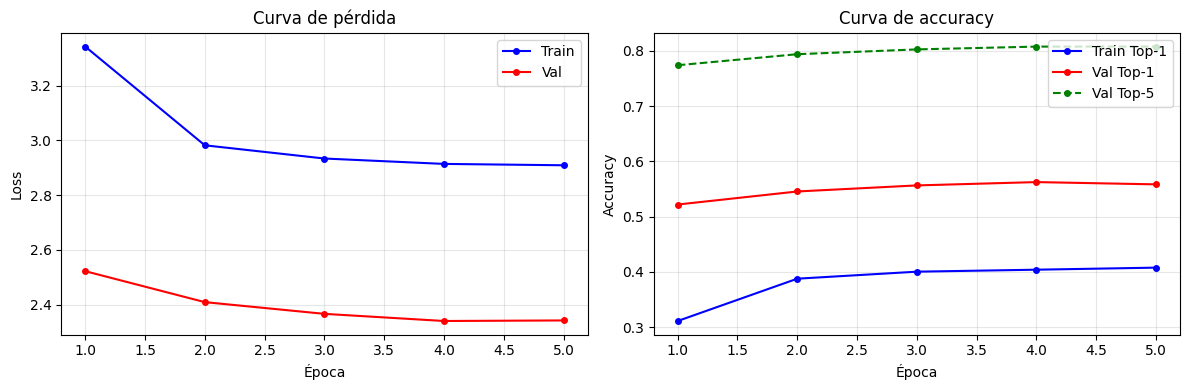


=== Métricas finales (mejor checkpoint) ===
Val Top-1: 0.563
Val Top-5: 0.808


In [6]:
fig = plot_training_curves(history)
plt.show()

print('\n=== Métricas finales (mejor checkpoint) ===')
print(f'Val Top-1: {max(history["val_top1"]):.3f}')
print(f'Val Top-5: {max(history["val_top5"]):.3f}')

---
## ❓ Preguntas de reflexión

1. **¿Qué accuracy Top-1 obtuvo el baseline?** ¿Era lo esperado (~60-70%)?
2. **¿Qué diferencia hay entre Top-1 y Top-5?** ¿Qué nos dice esto del modelo?
3. **¿El train loss converge o sigue bajando?** ¿Hay overfitting con solo la cabeza?
4. **¿Qué esperamos ganar** al descongelar el backbone en el notebook 03?
